# MRIxFields2026 — Baseline: CUT (0.1T → 7T)

Two-stage training pipeline for **Task 1** (single-pair translation):

1. **Preprocess** — NIfTI → 2D axial slices (NPZ, normalized to [0,1])
2. **Pretrain** — CUT (Contrastive Unpaired Translation) on retrospective unpaired data
3. **Finetune** — Supervised L1 + LPIPS on prospective paired data
4. **Inference** — Translate a 0.1T volume → 7T

> This notebook is self-contained — all model code is defined inline, no `from mrixfields` imports.
> We use only 3 retrospective + 1 prospective subject and 5 pretrain + 2 finetune epochs for demonstration.

In [1]:
import os
import functools
import numpy as np
import nibabel as nib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import init
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# Load environment from .env
for line in Path('../.env').read_text().splitlines():
    line = line.strip()
    if line and not line.startswith('#') and '=' in line:
        k, v = line.split('=', 1)
        os.environ.setdefault(k, v)

DATA_DIR = Path(os.environ['DATA_DIR'])
WORK_DIR = Path('tmp')
WORK_DIR.mkdir(exist_ok=True)

print(f'Data:  .../{DATA_DIR.name}')
print(f'Work:  {WORK_DIR}')

Device: cuda
Data:  .../release_20260414
Work:  tmp


## 1. Preprocess — NIfTI → 2D Axial Slices

Extract axial slices 72–291 (220 slices per volume) and save as compressed NPZ.

Volumes are **normalized to [0, 1]**; we cast to float32 and slice — no per-volume clipping or rescaling.

We only preprocess **0.1T** and **7T** (Task 1 pair), **T1W** modality:
- **Retrospective**: 3 subjects (unpaired, for CUT pretrain)
- **Prospective**: 1 subject (paired, for supervised finetune)

In [2]:
PREPROCESS_DIR = WORK_DIR / 'preprocessed'
SLICE_RANGE = (53, 203)  # 150 axial slices per volume

def preprocess_volume(nifti_path, output_dir, split_abbr, modality, field, subject_id):
    """Extract axial slices from a NIfTI volume and save as NPZ.

    Input volumes are in [0, 1]; we cast to float32 and slice without
    intensity rescaling.
    """
    output_dir.mkdir(parents=True, exist_ok=True)
    img = nib.load(nifti_path)
    data = nib.as_closest_canonical(img).get_fdata().astype(np.float32)

    count = 0
    for i in range(*SLICE_RANGE):
        slc = data[:, :, i]
        out = output_dir / f'{split_abbr}_{modality}_{field}_{subject_id}_s{i:03d}.npz'
        np.savez_compressed(out, image=slc)
        count += 1
    return count

# Retrospective: 3 subjects × 2 fields
print('--- Retrospective (3 subjects) ---')
for field in ['0.1T', '7T']:
    src_dir = DATA_DIR / 'Training_retrospective' / 'T1W' / field
    files = sorted(src_dir.glob('*.nii.gz'))[:3]
    out_dir = PREPROCESS_DIR / 'retro_train' / 'T1W' / field
    for f in files:
        sid = f.stem.split('_')[-1]
        n = preprocess_volume(f, out_dir, 'retro_train', 'T1W', field, sid)
        print(f'  {f.name} → {n} slices')

# Prospective: 1 subject × 2 fields
print('\n--- Prospective (1 subject) ---')
for field in ['0.1T', '7T']:
    src_dir = DATA_DIR / 'Training_prospective' / 'T1W' / field
    files = sorted(src_dir.glob('*.nii.gz'))[:1]
    out_dir = PREPROCESS_DIR / 'pro_train' / 'T1W' / field
    for f in files:
        sid = f.stem.split('_')[-1]
        n = preprocess_volume(f, out_dir, 'pro_train', 'T1W', field, sid)
        print(f'  {f.name} → {n} slices')

print(f'\nPreprocessed data: {PREPROCESS_DIR.relative_to(WORK_DIR.parent)}')

--- Retrospective (3 subjects) ---


  R_T1W_0.1T_0001.nii.gz → 150 slices


  R_T1W_0.1T_0002.nii.gz → 150 slices


  R_T1W_0.1T_0003.nii.gz → 150 slices


  R_T1W_7T_0822.nii.gz → 150 slices


  R_T1W_7T_0823.nii.gz → 150 slices


  R_T1W_7T_0824.nii.gz → 150 slices

--- Prospective (1 subject) ---


  P_T1W_0.1T_0006.nii.gz → 150 slices


  P_T1W_7T_0006.nii.gz → 150 slices

Preprocessed data: tmp/preprocessed


## 2. Dataset

- **UnpairedDataset**: Loads slices from one field strength independently (for CUT pretrain)
- **PairedDataset**: Loads matched source–target slice pairs by subject + slice index (for finetune)

Transform (CycleGAN/CUT): NormalizeMinMax (identity) → ToTensor(1,H,W) → Scale [0,1] → [−1,1] (no cropping — native 364×436 slices)
Transform (StarGAN v2): CenterCropOrPad(512,512) → NormalizeMinMax (identity) → ToTensor → Scale [−1,1]

In [3]:
class CenterCropOrPad:
    """Center-crop or zero-pad a 2D array to target_size."""
    def __init__(self, target_size=(364, 436)):
        self.th, self.tw = target_size

    def __call__(self, img):
        h, w = img.shape[:2]
        # Pad if needed
        pad_h, pad_w = max(self.th - h, 0), max(self.tw - w, 0)
        if pad_h > 0 or pad_w > 0:
            img = np.pad(img, ((pad_h // 2, pad_h - pad_h // 2),
                               (pad_w // 2, pad_w - pad_w // 2)), mode='constant')
            h, w = img.shape[:2]
        # Center crop
        sh, sw = (h - self.th) // 2, (w - self.tw) // 2
        return img[sh:sh + self.th, sw:sw + self.tw]

# CUT uses native (364, 436) slices — no cropping needed for this tutorial

def npz_to_tensor(img):
    """NPZ image [0,1] → tensor (1,H,W) [−1,1]."""
    t = torch.from_numpy(img).float().unsqueeze(0)  # (1, H, W)
    return t * 2.0 - 1.0  # [0,1] → [−1,1]


class UnpairedDataset(Dataset):
    """Load preprocessed NPZ slices for one field strength."""
    def __init__(self, base_dir, split, modality, field):
        self.files = sorted((Path(base_dir) / split / modality / field).glob('*.npz'))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        return {'image': npz_to_tensor(np.load(self.files[idx])['image'])}


class PairedDataset(Dataset):
    """Load paired source–target slices matched by subject + slice index."""
    def __init__(self, base_dir, split, modality, source_field, target_field):
        src_dir = Path(base_dir) / split / modality / source_field
        tgt_dir = Path(base_dir) / split / modality / target_field
        src_map = {self._key(f): f for f in sorted(src_dir.glob('*.npz'))}
        tgt_map = {self._key(f): f for f in sorted(tgt_dir.glob('*.npz'))}
        keys = sorted(set(src_map) & set(tgt_map))
        self.pairs = [(src_map[k], tgt_map[k]) for k in keys]

    @staticmethod
    def _key(p):
        parts = p.stem.split('_')
        return '_'.join(parts[-2:])  # e.g. "0006_s053"

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        s, t = self.pairs[idx]
        return {'source': npz_to_tensor(np.load(s)['image']),
                'target': npz_to_tensor(np.load(t)['image'])}


# Verify
ds_src = UnpairedDataset(PREPROCESS_DIR, 'retro_train', 'T1W', '0.1T')
ds_tgt = UnpairedDataset(PREPROCESS_DIR, 'retro_train', 'T1W', '7T')
ds_pair = PairedDataset(PREPROCESS_DIR, 'pro_train', 'T1W', '0.1T', '7T')
print(f'Retro 0.1T: {len(ds_src)}  |  Retro 7T: {len(ds_tgt)}  |  Pro paired: {len(ds_pair)}')

Retro 0.1T: 450  |  Retro 7T: 450  |  Pro paired: 150


## 3. Network Architecture

- **ResnetGenerator** — Encoder(2× downsample) → 9 ResNet blocks → Decoder(2× upsample) → Tanh
  - Supports `encode_only` mode: extract intermediate features for PatchNCE loss
- **NLayerDiscriminator** — PatchGAN (70×70 receptive field)
- **PatchSampleF** — Sample spatial patches from feature maps + MLP projection for contrastive learning

In [4]:
class ResnetBlock(nn.Module):
    """ResNet block: x + Conv-Norm-ReLU-Conv-Norm(x)."""
    def __init__(self, dim, norm_layer, use_dropout, use_bias):
        super().__init__()
        block = [nn.ReflectionPad2d(1),
                 nn.Conv2d(dim, dim, 3, bias=use_bias), norm_layer(dim), nn.ReLU(True)]
        if use_dropout:
            block += [nn.Dropout(0.5)]
        block += [nn.ReflectionPad2d(1),
                  nn.Conv2d(dim, dim, 3, bias=use_bias), norm_layer(dim)]
        self.conv_block = nn.Sequential(*block)

    def forward(self, x):
        return x + self.conv_block(x)


class ResnetGenerator(nn.Module):
    """CUT/CycleGAN generator: c7s1-ngf, d-2ngf, d-4ngf, R×9, u-2ngf, u-ngf, c7s1-out, Tanh.

    Args:
        layers (list): Layer indices for intermediate feature extraction (CUT NCE loss).
        encode_only (bool): If True, return only intermediate features (stop early).
    """
    def __init__(self, input_nc=1, output_nc=1, ngf=64, n_blocks=9,
                 norm_layer=nn.InstanceNorm2d, use_dropout=False):
        super().__init__()
        use_bias = (norm_layer == nn.InstanceNorm2d)

        model = [nn.ReflectionPad2d(3),
                 nn.Conv2d(input_nc, ngf, 7, bias=use_bias), norm_layer(ngf), nn.ReLU(True)]
        # Downsample
        for i in range(2):
            mult = 2 ** i
            model += [nn.Conv2d(ngf * mult, ngf * mult * 2, 3, stride=2, padding=1, bias=use_bias),
                      norm_layer(ngf * mult * 2), nn.ReLU(True)]
        # ResNet blocks
        mult = 4
        for _ in range(n_blocks):
            model += [ResnetBlock(ngf * mult, norm_layer, use_dropout, use_bias)]
        # Upsample
        for i in range(2):
            mult = 2 ** (2 - i)
            model += [nn.ConvTranspose2d(ngf * mult, ngf * mult // 2, 3,
                                         stride=2, padding=1, output_padding=1, bias=use_bias),
                      norm_layer(ngf * mult // 2), nn.ReLU(True)]
        model += [nn.ReflectionPad2d(3), nn.Conv2d(ngf, output_nc, 7), nn.Tanh()]
        self.model = nn.Sequential(*model)

    def forward(self, x, layers=[], encode_only=False):
        if len(layers) > 0:
            feat = x
            feats = []
            for layer_id, layer in enumerate(self.model):
                feat = layer(feat)
                if layer_id in layers:
                    feats.append(feat)
                if layer_id == layers[-1] and encode_only:
                    return feats
            return feat, feats
        return self.model(x)

print(f'ResnetGenerator params: {sum(p.numel() for p in ResnetGenerator().parameters()):,}')

ResnetGenerator params: 11,365,633


In [5]:
class NLayerDiscriminator(nn.Module):
    """PatchGAN discriminator (70×70 receptive field with n_layers=3)."""
    def __init__(self, input_nc=1, ndf=64, n_layers=3, norm_layer=nn.InstanceNorm2d):
        super().__init__()
        use_bias = (norm_layer == nn.InstanceNorm2d)
        kw, padw = 4, 1
        seq = [nn.Conv2d(input_nc, ndf, kw, stride=2, padding=padw), nn.LeakyReLU(0.2, True)]
        nf_mult = 1
        for n in range(1, n_layers):
            nf_mult_prev = nf_mult
            nf_mult = min(2 ** n, 8)
            seq += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kw, stride=2, padding=padw, bias=use_bias),
                    norm_layer(ndf * nf_mult), nn.LeakyReLU(0.2, True)]
        nf_mult_prev = nf_mult
        nf_mult = min(2 ** n_layers, 8)
        seq += [nn.Conv2d(ndf * nf_mult_prev, ndf * nf_mult, kw, stride=1, padding=padw, bias=use_bias),
                norm_layer(ndf * nf_mult), nn.LeakyReLU(0.2, True)]
        seq += [nn.Conv2d(ndf * nf_mult, 1, kw, stride=1, padding=padw)]
        self.model = nn.Sequential(*seq)

    def forward(self, x):
        return self.model(x)


class Normalize(nn.Module):
    """L2-normalize along dim=1."""
    def forward(self, x):
        return x / (x.pow(2).sum(1, keepdim=True).sqrt() + 1e-7)


class PatchSampleF(nn.Module):
    """Sample spatial patches + MLP projection for PatchNCE loss."""
    def __init__(self, nc=256):
        super().__init__()
        self.l2norm = Normalize()
        self.nc = nc
        self.mlp_init = False

    def create_mlp(self, feats):
        for mlp_id, feat in enumerate(feats):
            mlp = nn.Sequential(nn.Linear(feat.shape[1], self.nc), nn.ReLU(),
                                nn.Linear(self.nc, self.nc))
            mlp.to(feat.device)
            setattr(self, f'mlp_{mlp_id}', mlp)
        init_weights(self)
        self.mlp_init = True

    def forward(self, feats, num_patches=256, patch_ids=None):
        return_ids, return_feats = [], []
        if not self.mlp_init:
            self.create_mlp(feats)
        for feat_id, feat in enumerate(feats):
            B, H, W = feat.shape[0], feat.shape[2], feat.shape[3]
            feat_reshape = feat.permute(0, 2, 3, 1).flatten(1, 2)  # (B, H*W, C)
            if patch_ids is not None:
                patch_id = patch_ids[feat_id]
            else:
                patch_id = np.random.permutation(feat_reshape.shape[1])[:num_patches]
            patch_id = torch.tensor(patch_id, dtype=torch.long, device=feat.device)
            x_sample = feat_reshape[:, patch_id, :].flatten(0, 1)  # (B*P, C)
            x_sample = getattr(self, f'mlp_{feat_id}')(x_sample)
            x_sample = self.l2norm(x_sample)
            return_feats.append(x_sample)
            return_ids.append(patch_id)
        return return_feats, return_ids


def init_weights(net, gain=0.02):
    """Initialize Conv/Linear with N(0, 0.02), BatchNorm with N(1, 0.02)."""
    def _init(m):
        name = m.__class__.__name__
        if hasattr(m, 'weight') and ('Conv' in name or 'Linear' in name):
            init.normal_(m.weight.data, 0.0, gain)
            if m.bias is not None:
                init.constant_(m.bias.data, 0.0)
        elif 'BatchNorm2d' in name:
            init.normal_(m.weight.data, 1.0, gain)
            init.constant_(m.bias.data, 0.0)
    net.apply(_init)

print(f'NLayerDiscriminator params: {sum(p.numel() for p in NLayerDiscriminator().parameters()):,}')

NLayerDiscriminator params: 2,762,689


## 4. Losses

- **GANLoss** — Least-squares GAN (MSE): `(D(x) − target)²`
- **PatchNCELoss** — InfoNCE per spatial patch: positive = same location, negatives = other locations
- **PerceptualLoss** — LPIPS (AlexNet) for supervised finetune

In [6]:
class GANLoss(nn.Module):
    """LSGAN loss: MSE against real/fake label."""
    def __init__(self):
        super().__init__()
        self.register_buffer('real_label', torch.tensor(1.0))
        self.register_buffer('fake_label', torch.tensor(0.0))
        self.loss = nn.MSELoss()

    def forward(self, pred, is_real):
        target = (self.real_label if is_real else self.fake_label).expand_as(pred)
        return self.loss(pred, target)


class PatchNCELoss(nn.Module):
    """Patch-wise InfoNCE loss for CUT.

    Same-location patches are positives, all other locations are negatives.
    """
    def __init__(self, nce_T=0.07):
        super().__init__()
        self.nce_T = nce_T
        self.ce = nn.CrossEntropyLoss(reduction='none')

    def forward(self, feat_q, feat_k):
        num_patches = feat_q.shape[0]
        feat_k = feat_k.detach()

        # Positive: dot product at same location → (P, 1)
        l_pos = (feat_q * feat_k).sum(dim=1, keepdim=True)

        # Negative: all cross-location dot products → (P, P)
        l_neg = feat_q @ feat_k.t()
        diagonal = torch.eye(num_patches, device=feat_q.device, dtype=torch.bool)
        l_neg.masked_fill_(diagonal, -10.0)

        logits = torch.cat([l_pos, l_neg], dim=1) / self.nce_T  # (P, 1+P)
        labels = torch.zeros(num_patches, dtype=torch.long, device=feat_q.device)
        return self.ce(logits, labels)


class PerceptualLoss(nn.Module):
    """LPIPS perceptual loss (AlexNet)."""
    def __init__(self):
        super().__init__()
        import lpips
        self.fn = lpips.LPIPS(net='alex')
        for p in self.fn.parameters():
            p.requires_grad = False

    def forward(self, pred, target):
        # LPIPS expects 3-channel input
        return self.fn(pred.repeat(1, 3, 1, 1), target.repeat(1, 3, 1, 1)).mean()

print('Losses defined.')

Losses defined.


## 5. CUT Model

Wraps Generator (G), Discriminator (D), and Projection Network (F) into one module.

**Loss = λ_GAN · GAN(D, G(x)) + λ_NCE · NCE(G(x), x) + λ_NCE · NCE(G(y), y)**

Key methods:
- `data_dependent_initialize(A, B)` — Lazily builds netF MLPs on first forward pass
- `optimize_parameters(A, B)` — One full training step (D update → G+F update)

In [7]:
class CUTModel(nn.Module):
    def __init__(self, ngf=64, ndf=64, n_blocks=9,
                 nce_layers=None, nce_T=0.07, num_patches=256,
                 lambda_GAN=1.0, lambda_NCE=1.0, nce_idt=True,
                 lr=0.0002, beta1=0.5, beta2=0.999):
        super().__init__()
        if nce_layers is None:
            nce_layers = [0, 4, 8, 12, 16]
        self.nce_layers = nce_layers
        self.num_patches = num_patches
        self.lambda_GAN = lambda_GAN
        self.lambda_NCE = lambda_NCE
        self.nce_idt = nce_idt
        self.lr, self.beta1, self.beta2 = lr, beta1, beta2

        self.netG = ResnetGenerator(1, 1, ngf, n_blocks)
        self.netD = NLayerDiscriminator(1, ndf)
        self.netF = PatchSampleF(nc=256)
        self.criterionGAN = GANLoss()
        self.criterionNCE = nn.ModuleList([PatchNCELoss(nce_T) for _ in nce_layers])

    def _init_weights(self):
        init_weights(self.netG)
        init_weights(self.netD)

    def data_dependent_initialize(self, real_A, real_B):
        """Run one forward + backward to build netF MLPs, then create optimizer_F."""
        self.forward(real_A, real_B)
        self.compute_D_loss(real_A, real_B).backward()
        self.compute_G_loss(real_A, real_B).backward()
        self.optimizer_F = torch.optim.Adam(self.netF.parameters(),
                                            lr=self.lr, betas=(self.beta1, self.beta2))

    def setup_optimizers(self):
        self.optimizer_G = torch.optim.Adam(self.netG.parameters(),
                                            lr=self.lr, betas=(self.beta1, self.beta2))
        self.optimizer_D = torch.optim.Adam(self.netD.parameters(),
                                            lr=self.lr, betas=(self.beta1, self.beta2))

    def forward(self, real_A, real_B):
        if self.nce_idt and self.training:
            real = torch.cat((real_A, real_B), dim=0)
        else:
            real = real_A
        fake = self.netG(real)
        self.fake_B = fake[:real_A.size(0)]
        if self.nce_idt and self.training:
            self.idt_B = fake[real_A.size(0):]
        return self.fake_B

    def compute_D_loss(self, real_A, real_B):
        pred_fake = self.netD(self.fake_B.detach())
        pred_real = self.netD(real_B)
        return 0.5 * (self.criterionGAN(pred_fake, False).mean()
                     + self.criterionGAN(pred_real, True).mean())

    def compute_G_loss(self, real_A, real_B):
        # GAN loss
        loss_G = self.lambda_GAN * self.criterionGAN(self.netD(self.fake_B), True).mean()
        # NCE loss
        loss_NCE = self._nce_loss(real_A, self.fake_B)
        if self.nce_idt and self.training:
            loss_NCE = (loss_NCE + self._nce_loss(real_B, self.idt_B)) * 0.5
        return loss_G + loss_NCE

    def _nce_loss(self, src, tgt):
        feat_q = self.netG(tgt, self.nce_layers, encode_only=True)
        feat_k = self.netG(src, self.nce_layers, encode_only=True)
        feat_k_pool, sample_ids = self.netF(feat_k, self.num_patches, None)
        feat_q_pool, _ = self.netF(feat_q, self.num_patches, sample_ids)
        total = 0.0
        for fq, fk, crit in zip(feat_q_pool, feat_k_pool, self.criterionNCE):
            total += (crit(fq, fk) * self.lambda_NCE).mean()
        return total / len(self.nce_layers)

    def optimize_parameters(self, real_A, real_B):
        self.forward(real_A, real_B)
        # Update D
        for p in self.netD.parameters(): p.requires_grad = True
        self.optimizer_D.zero_grad()
        loss_D = self.compute_D_loss(real_A, real_B)
        loss_D.backward()
        self.optimizer_D.step()
        # Update G + F
        for p in self.netD.parameters(): p.requires_grad = False
        self.optimizer_G.zero_grad()
        self.optimizer_F.zero_grad()
        loss_G = self.compute_G_loss(real_A, real_B)
        loss_G.backward()
        self.optimizer_G.step()
        self.optimizer_F.step()
        return {'loss_D': loss_D.item(), 'loss_G': loss_G.item()}

print('CUTModel defined.')

CUTModel defined.


## 6. Stage 1 — Pretrain (CUT on Retrospective)

Unpaired training: 0.1T slices (source) and 7T slices (target) are sampled independently.

- Generator learns to translate 0.1T → 7T via adversarial + contrastive loss
- 5 epochs for demonstration (full training uses 100 + 100 decay)

In [8]:
# Build model
model = CUTModel().to(DEVICE)
model._init_weights()

# Unpaired data loaders
loader_src = DataLoader(ds_src, batch_size=4, shuffle=True, num_workers=2, drop_last=True)
loader_tgt = DataLoader(ds_tgt, batch_size=4, shuffle=True, num_workers=2, drop_last=True)

# Data-dependent init (builds netF MLPs)
batch_a = next(iter(loader_src))
batch_b = next(iter(loader_tgt))
model.data_dependent_initialize(batch_a['image'].to(DEVICE), batch_b['image'].to(DEVICE))
model.setup_optimizers()

# Train 5 epochs
N_EPOCHS_PRETRAIN = 5
history_pretrain = {'loss_D': [], 'loss_G': []}

for epoch in range(N_EPOCHS_PRETRAIN):
    model.train()
    iter_src = iter(loader_src)
    iter_tgt = iter(loader_tgt)
    n_iters = min(len(loader_src), len(loader_tgt))
    epoch_D, epoch_G = 0.0, 0.0

    for i in range(n_iters):
        real_A = next(iter_src)['image'].to(DEVICE)
        real_B = next(iter_tgt)['image'].to(DEVICE)
        losses = model.optimize_parameters(real_A, real_B)
        epoch_D += losses['loss_D']
        epoch_G += losses['loss_G']
        if (i + 1) % 20 == 0:
            print(f'  Epoch {epoch+1} iter {i+1}/{n_iters}  D={losses["loss_D"]:.4f}  G={losses["loss_G"]:.4f}')

    history_pretrain['loss_D'].append(epoch_D / n_iters)
    history_pretrain['loss_G'].append(epoch_G / n_iters)
    print(f'Epoch {epoch+1}/{N_EPOCHS_PRETRAIN}  avg_D={epoch_D/n_iters:.4f}  avg_G={epoch_G/n_iters:.4f}')

# Save pretrained generator
pretrain_ckpt = WORK_DIR / 'pretrain_generator.pth'
torch.save(model.netG.state_dict(), pretrain_ckpt)
print(f'\nSaved pretrained generator: {pretrain_ckpt}')

/tmp/ipykernel_525373/2883733391.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  patch_id = torch.tensor(patch_id, dtype=torch.long, device=feat.device)


/tmp/ipykernel_525373/2883733391.py:59: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  patch_id = torch.tensor(patch_id, dtype=torch.long, device=feat.device)


  Epoch 1 iter 20/112  D=0.2081  G=6.6501


  Epoch 1 iter 40/112  D=0.1611  G=6.0238


  Epoch 1 iter 60/112  D=0.1364  G=5.7111


...

  Epoch 5 iter 60/112  D=0.2805  G=3.7421


  Epoch 5 iter 80/112  D=0.2896  G=4.2242


  Epoch 5 iter 100/112  D=0.2368  G=4.0312


Epoch 5/5  avg_D=0.2605  avg_G=3.9249



Saved pretrained generator: tmp/pretrain_generator.pth


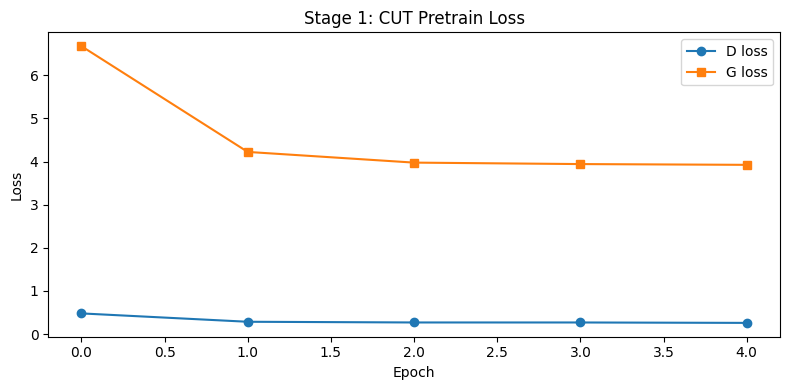

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_pretrain['loss_D'], 'o-', label='D loss')
ax.plot(history_pretrain['loss_G'], 's-', label='G loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Stage 1: CUT Pretrain Loss')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Stage 2 — Finetune (Supervised on Prospective)

Load the pretrained generator and fine-tune with **paired** data using:
- **L1 loss** (weight 1.0) — pixel-level reconstruction
- **LPIPS loss** (weight 0.1) — perceptual similarity

Only the generator is kept; D and netF are discarded.

Loaded pretrained generator
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/jh/miniconda3/envs/mf/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jh/miniconda3/envs/mf/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/jh/miniconda3/envs/mf/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth


  Epoch 1 iter 10/37  loss=0.0366


  Epoch 1 iter 20/37  loss=0.0301


...

  Epoch 2 iter 10/37  loss=0.0508


  Epoch 2 iter 20/37  loss=0.0754


  Epoch 2 iter 30/37  loss=0.0363


Epoch 2/2  avg_loss=0.0447



Saved finetuned generator: tmp/finetune_generator.pth


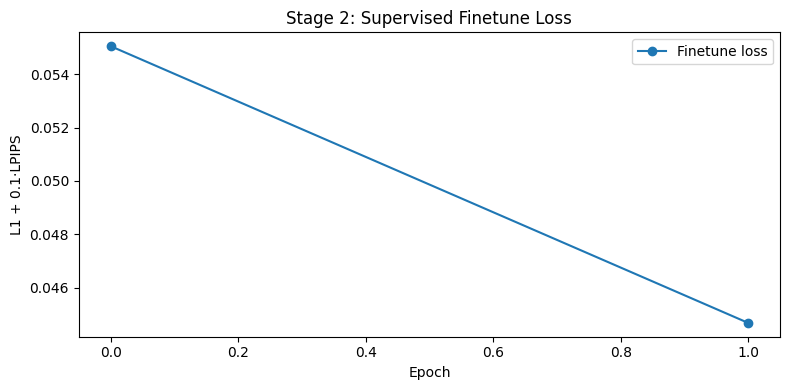

In [10]:
# Load pretrained generator
generator = ResnetGenerator(1, 1, 64, 9).to(DEVICE)
generator.load_state_dict(torch.load(pretrain_ckpt, map_location=DEVICE, weights_only=True))
print('Loaded pretrained generator')

# Losses
criterion_l1 = nn.L1Loss()
criterion_lpips = PerceptualLoss().to(DEVICE)

optimizer = torch.optim.Adam(generator.parameters(), lr=5e-5, betas=(0.5, 0.999))
loader_pair = DataLoader(ds_pair, batch_size=4, shuffle=True, num_workers=2, drop_last=True)

# Train 2 epochs
N_EPOCHS_FINETUNE = 2
history_finetune = []

for epoch in range(N_EPOCHS_FINETUNE):
    generator.train()
    epoch_loss = 0.0
    for i, batch in enumerate(loader_pair):
        source = batch['source'].to(DEVICE)
        target = batch['target'].to(DEVICE)

        pred = generator(source)
        loss = 1.0 * criterion_l1(pred, target) + 0.1 * criterion_lpips(pred, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        if (i + 1) % 10 == 0:
            print(f'  Epoch {epoch+1} iter {i+1}/{len(loader_pair)}  loss={loss.item():.4f}')

    avg = epoch_loss / len(loader_pair)
    history_finetune.append(avg)
    print(f'Epoch {epoch+1}/{N_EPOCHS_FINETUNE}  avg_loss={avg:.4f}')

# Save finetuned generator
finetune_ckpt = WORK_DIR / 'finetune_generator.pth'
torch.save(generator.state_dict(), finetune_ckpt)
print(f'\nSaved finetuned generator: {finetune_ckpt}')

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_finetune, 'o-', label='Finetune loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('L1 + 0.1·LPIPS')
ax.set_title('Stage 2: Supervised Finetune Loss')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Inference

Translate a full 3D 0.1T volume to 7T, slice by slice:
1. Input volume is in [0, 1]
2. For each axial slice (364×436): scale to [−1, 1] → Generator → scale back to [0, 1]
3. Visualize input vs. prediction at mid-slice

Source: P_T1W_0.1T_0007.nii.gz
Target: P_T1W_7T_0007.nii.gz


Prediction shape: (364, 436, 364)


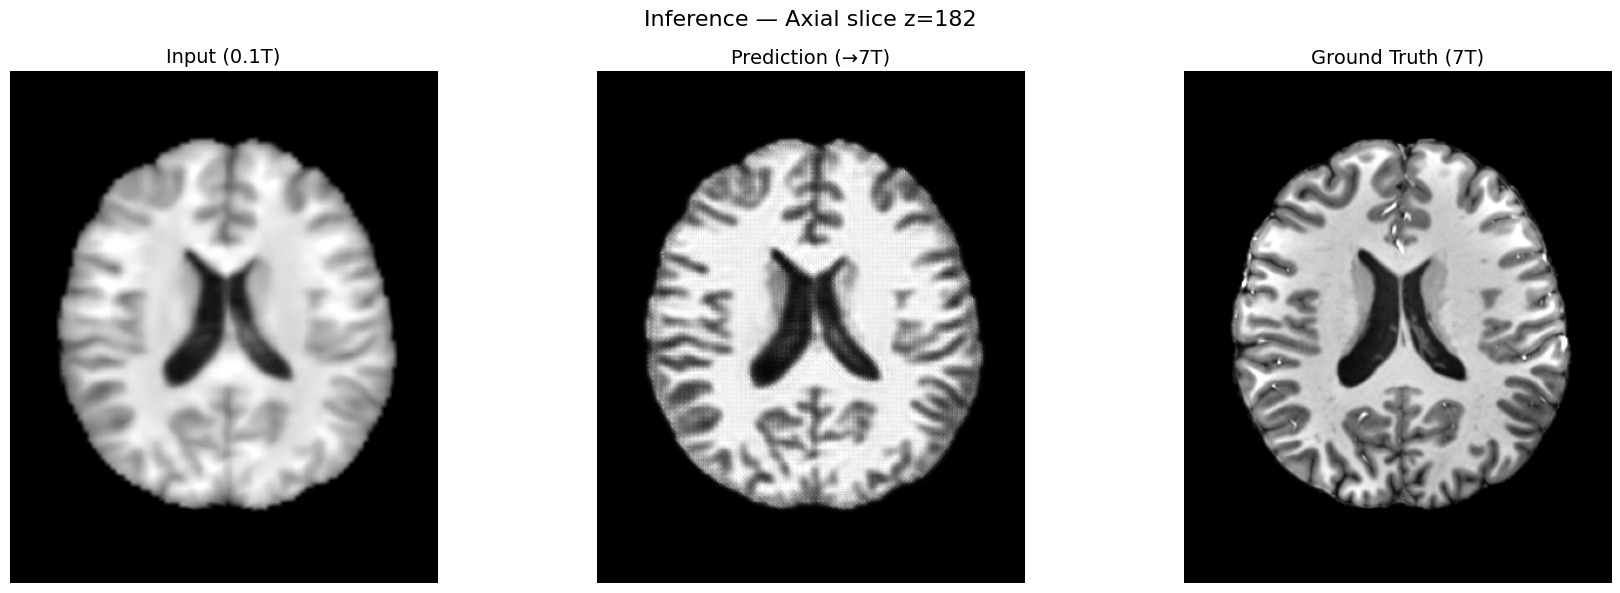

Saved: tmp/inference/P_T1W_0.1T_0007.nii.gz
Saved: tmp/inference/P_T1W_7T_0007_pred.nii.gz


In [11]:
# Load finetuned generator
generator.load_state_dict(torch.load(finetune_ckpt, map_location=DEVICE, weights_only=True))
generator.eval()

# Pick subject 0007 (not used in fine-tuning, which only used 0006)
src_path = DATA_DIR / 'Training_prospective' / 'T1W' / '0.1T' / 'P_T1W_0.1T_0007.nii.gz'
tgt_path = DATA_DIR / 'Training_prospective' / 'T1W' / '7T'  / 'P_T1W_7T_0007.nii.gz'
print(f'Source: {src_path.name}')
print(f'Target: {tgt_path.name}')

# Load
src_img = nib.load(src_path)
src_vol = nib.as_closest_canonical(src_img).get_fdata().astype(np.float32)
tgt_vol = nib.as_closest_canonical(nib.load(tgt_path)).get_fdata().astype(np.float32)

# Predict slice by slice
pred_vol = np.zeros_like(src_vol)

with torch.no_grad():
    for i in range(src_vol.shape[2]):
        slc = src_vol[:, :, i]  # (364, 436)
        t = torch.from_numpy(slc * 2.0 - 1.0).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
        out = generator(t).squeeze().cpu().numpy()  # (364, 436)
        out = np.clip(out, -1, 1) * 0.5 + 0.5      # [-1,1] -> [0,1]
        pred_vol[:, :, i] = out

print(f'Prediction shape: {pred_vol.shape}')

# Visualize mid-slice
z = src_vol.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# vmax = 99.5th percentile per slice: suppresses the top 0.5% bright outliers so mid-tone contrast isn't washed out.
axes[0].imshow(src_vol[:, :, z].T, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(src_vol[:, :, z], 99.5))
axes[0].set_title('Input (0.1T)', fontsize=14)

axes[1].imshow(pred_vol[:, :, z].T, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(pred_vol[:, :, z], 99.5))
axes[1].set_title('Prediction (→7T)', fontsize=14)

axes[2].imshow(tgt_vol[:, :, z].T, cmap='gray', origin='lower', vmin=0, vmax=np.percentile(tgt_vol[:, :, z], 99.5))
axes[2].set_title('Ground Truth (7T)', fontsize=14)

for ax in axes:
    ax.axis('off')
fig.suptitle(f'Inference — Axial slice z={z}', fontsize=16)
plt.tight_layout()
plt.show()

# Save source and prediction to tmp/inference/
import shutil
inference_dir = WORK_DIR / 'inference'
inference_dir.mkdir(exist_ok=True)

# Copy original source NIfTI
shutil.copy2(src_path, inference_dir / src_path.name)

# Save prediction as NIfTI (reuse source affine)
pred_img = nib.Nifti1Image(pred_vol.astype(np.float32), nib.as_closest_canonical(src_img).affine)
pred_out = inference_dir / src_path.name.replace('0.1T', '7T').replace('.nii.gz', '_pred.nii.gz')
nib.save(pred_img, pred_out)
print(f'Saved: {(inference_dir / src_path.name).relative_to(WORK_DIR.parent)}')
print(f'Saved: {pred_out.relative_to(WORK_DIR.parent)}')

## Summary

| Stage | Data | Loss | Epochs (demo) |
|-------|------|------|---------------|
| Pretrain | Retro unpaired (3 subj) | GAN + PatchNCE | 5 |
| Finetune | Pro paired (1 subj) | L1 + 0.1·LPIPS | 2 |

Full training uses 100+100 epochs (pretrain) and 50 epochs (finetune).

Volume shape: 364×436×364. CycleGAN/CUT use native (364, 436) slices; StarGAN v2 pads to 512×512.

**Next:** See `03_evaluation.ipynb` for quantitative evaluation (nRMSE, SSIM, LPIPS, Dice).